In [14]:
import os
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pickle  #파일저장에
from tqdm.notebook import tqdm  # 학습 진행 상황 시각화를 위해 추가
from PIL import Image
import re

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import roc_auc_score

# --- 설정 (Configuration) ---
BATCH_SIZE = 32  # 메모리에 맞춰 조절 (16 or 32)
LEARNING_RATE = 0.0001 # 전이 학습은 학습률을 낮게 잡습니다
NUM_EPOCHS = 10
IMAGE_SIZE = 320
BASE_DIR  = "/kaggle/input/chexpert/"

MODEL_SAVE_PATH_PTH = '/kaggle/input/x-ray/pytorch/default/1/x-ray_history_denseNet-121_v1.pth'
HISTORY_FILEPATH = '/kaggle/input/x-ray/pytorch/default/1/x-ray_history_denseNet-121_v1.pkl'

# GPU 사용 가능 여부 확인
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {DEVICE}")

CHEXPERT14 = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax',
    'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
]
NUM_CLASSES = len(CHEXPERT14)
train_df = pd.read_csv(BASE_DIR+'train.csv')
val_df = pd.read_csv(BASE_DIR+'valid.csv')

print(f"train 데이터 개수: {len(train_df)}")
print(f"valid 데이터 개수: {len(val_df)}")


사용 중인 디바이스: cpu
train 데이터 개수: 223414
valid 데이터 개수: 234


In [15]:
class CheXpertDataset(Dataset):
    def __init__(self, metadata, transform=None):
        
        df = metadata.copy()
        df[CHEXPERT14] = df[CHEXPERT14].fillna(0)
        
        # -1을 모두 1로 변경
        df[CHEXPERT14] = df[CHEXPERT14].replace(-1, 1)
        
        # -1을 모두 0으로 변경
        # df[CHEXPERT14] = df[CHEXPERT14].replace(-1, 0)

        self.metadata = df
        self.transform = transform

        
    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # 이미지 경로 찾기
        img_path = self.metadata.iloc[idx]['Path'].replace("CheXpert-v1.0-small/","")
        
        # 이미지 로드 및 RGB 변환 (DenseNet은 3채널 입력 필요)
        image = Image.open(os.path.join(BASE_DIR, img_path)).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # 레이블 처리 (Multi-label)
        labels = self.metadata.iloc[idx][CHEXPERT14].values.astype('float32')
                
        return image, torch.from_numpy(labels).clone()

In [16]:
# 모델 정의 (DenseNet-121 Transfer Learning)
def get_model(num_classes):
    model = models.densenet121(weights='IMAGENET1K_V1')
    
    for param in model.parameters():
        param.requires_grad = False
    
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),                # 과적합 방지
        nn.Linear(model.classifier.in_features, num_classes)     # 최종 출력
    )
    return model
    
model = get_model(NUM_CLASSES)
model = model.to(DEVICE)

In [17]:
# 데이터 로딩 및 학습 함수 (검증 단계 및 출력 추가)
def DataIncrease():

    train_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),       # 좌우 반전
        transforms.RandomRotation(15),           # -10~10도 회전
        transforms.ColorJitter(brightness=0.1, contrast=0.1), # 명암 조절 중요
        transforms.ToTensor(),
        # ImageNet 학습 데이터의 평균/표준편차로 정규화 (필수)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    #검증 데이터 전처리 (val_transforms)검증 단계에서는 데이터의 정확한 성능을 측정해야 하므로 무작위 변환을 피합니다.
    val_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
                                                                            

    # DataLoader 생성
    train_dataset = CheXpertDataset(train_df, transform=train_transforms)
    val_dataset = CheXpertDataset(val_df, transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    # 각 질병별 양성(환자) 데이터 개수 카운트
    pos_counts = []
    for label in CHEXPERT14:
        # 해당 질병이 포함된 행의 개수
        count = (train_df[label] == 1.0).sum()
        pos_counts.append(max(count, 1)) # 0으로 나누기 방지

    pos_counts = torch.tensor(pos_counts).float().to(DEVICE)
    total_count = len(train_df)
    neg_counts = total_count - pos_counts

    # 개수에 반비례해 계산된 가중치:
    # tensor([8.9823, 8.9823, 8.9823, 8.9823, 8.9823, 8.9823, 8.9823, 8.9823, 8.9823, 8.9823])
    pos_weight = neg_counts / pos_counts
    
    # 루트 씌운 개수에 계산된 가중치 결과
    # tensor([2.3008, 3.0297, 2.1132, 0.7495, 3.1913, 1.4531, 2.7155, 3.6108, 1.9012, 2.4413, 0.9525, 4.1497, 3.2074, 0.6554])
    final_weight = torch.log1p(pos_weight)
    
    print("자동 계산된 가중치:", final_weight) 

    # 3. 손실 함수에 적용
    criterion = nn.BCEWithLogitsLoss(pos_weight=final_weight) # 내부적으로 Sigmoid 동작
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    
    best_val_auc = 0.0  # 가장 좋은 성능의 모델을 저장하기 위함
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_auc': [],          # 전체 14개 클래스 평균 AUROC
        'val_auc_top5': [],
    }
    
    # 1. 스케일러 정의 (학습 루프 시작 전)
    scaler = torch.amp.GradScaler('cuda')

    print("PyTorch 모델 학습 시작...")
    for epoch in range(NUM_EPOCHS):
        
        if epoch == 2:
            for param in model.parameters():
                param.requires_grad = True

            for param_group in optimizer.param_groups:
                param_group['lr'] = LEARNING_RATE * 0.1

        # 훈련 단계 (Training Step)
        model.train()
        # CheXpert 리더보드 기준 5대 질환 인덱스
        # ['Cardiomegaly'(2), 'Edema'(5), 'Consolidation'(6), 'Atelectasis'(8), 'Pleural Effusion'(10)]
        TOP5_INDICES = [2, 5, 6, 8, 10]
        train_loss = 0.0
        
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]", leave=True)
        #훈련중인 부분을 보이게 하려고 한다. 
        for images, labels in train_loop:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            labels = labels.float() # 그 다음 float로 변환
            optimizer.zero_grad()

            # [수정] autocast 적용
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            # [수정] scaler로 역전파
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # 검증 단계 (Validation Step)
        model.eval()
        val_loss = 0
        all_labels = []
        all_probs = [] # AUC용 (확률값 0.0~1.0)
        
        val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Validation]", leave=True)
        with torch.no_grad():
            for images, labels in val_loop:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                labels = labels.float()

                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                val_loss += loss.item()

                # 확률값(Sigmoid) 저장
                probs = torch.sigmoid(outputs)
                
                all_labels.append(labels.cpu().numpy())
                all_probs.append(probs.cpu().numpy())
            
        # 모든 배치의 데이터를 합침
        all_labels = np.vstack(all_labels)
        all_probs = np.vstack(all_probs)
        avg_val_loss = val_loss / len(val_loader)

        # Mean AUC-ROC 계산
        # 데이터가 존재하는(양성/음성 모두 있는) 클래스만 추출하여 계산
        valid_auc_list = []
        for i in range(NUM_CLASSES):
            # 해당 클래스에 0과 1이 모두 있는지 확인
            if len(np.unique(all_labels[:, i])) > 1:
                score = roc_auc_score(all_labels[:, i], all_probs[:, i])
                valid_auc_list.append(score)
        
        auc_score = np.mean(valid_auc_list) if valid_auc_list else 0.5
        
        # 핵심 질환 AUROC
        auc_top5 = roc_auc_score(all_labels[:, TOP5_INDICES], all_probs[:, TOP5_INDICES], average='macro')

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(auc_score)
        history['val_auc_top5'].append(auc_top5)
        
        # 학습 루프(Validation 단계 끝난 후)에 추가
        scheduler.step(avg_val_loss)
        
        print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Mean AUC: {auc_score:.4f} | Top 5 AUC: {auc_top5:.4f}")

        # [전략] Best 모델 저장 (Top 5 AUC 기준)
        if auc_top5 > best_val_auc:
            best_val_auc = auc_top5
            torch.save(model.state_dict(), MODEL_SAVE_PATH_PTH)
            print(f"*** Best 모델 갱신 (Top 5 AUC: {best_val_auc:.4f}) -> 저장 완료")
        
    print("학습 완료!")
    
    # 모델 저장  - model.state_dict() :가중치
    torch.save(model.state_dict(), MODEL_SAVE_PATH_PTH)
    print(f"모델 가중치가 '{MODEL_SAVE_PATH_PTH}'에 저장되었습니다.")
    
    # 히스토리 저장
    with open(HISTORY_FILEPATH, 'wb') as file:
        pickle.dump(history, file)
    print(f"학습 히스토리가 '{HISTORY_FILEPATH}'에 저장되었습니다.")


def train_data_load():
    model = get_model(NUM_CLASSES)
    model = model.to(DEVICE)
    
    history = None
    
    if not os.path.exists(MODEL_SAVE_PATH_PTH):
        print(f"저장된 모델 파일이 없습니다: {MODEL_SAVE_PATH_PTH}")
        return False, None, None
        
    try:
        # map_location 추가 (GPU/CPU 호환성)
        model.load_state_dict(torch.load(MODEL_SAVE_PATH_PTH, map_location=DEVICE))
        print(f"모델 로드 성공: '{MODEL_SAVE_PATH_PTH}'")
    except Exception as e:
        print(f"모델 로드 중 오류 발생: {e}")
        return False, None, None
    
    if os.path.exists(HISTORY_FILEPATH):
        try:
            with open(HISTORY_FILEPATH, 'rb') as file:
                history = pickle.load(file)
                print(f"히스토리 로드 성공.")
        except Exception as e:
            print(f"히스토리 로드 오류: {e}")
    else:
        print("히스토리 파일이 없습니다.")
    
    return True, history, model

# 평가 함수 (LoadModels)
def LoadModels():
    rf, history, model = train_data_load()

    if not rf:
        print("데이터를 로드하는 데 실패했습니다.")
        return rf

    # 그래프 그리기
    plt.figure(figsize=(18, 5))

    # Loss 그래프
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue', linestyle='--')
    plt.plot(history['val_loss'], label='Val Loss', color='red')
    plt.title('Loss Over Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Mean AUC와 Top 5 AUC
    plt.subplot(1, 3, 2)
    plt.plot(history['val_auc'], label='Mean AUC (All)', color='green', marker='o')
    plt.plot(history['val_auc_top5'], label='Top 5 AUC (Critical)', color='orange', marker='s')
    plt.axhline(y=0.5, color='gray', linestyle=':', label='Random Guess') # 0.5 기준선
    plt.title('AUC-ROC: All vs Top 5', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('AUC Score')
    plt.ylim(0.4, 1.0) # 의료 AI 점수대는 보통 이 범위 내에 있음
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout() # 그래프 간격 자동 조절
    
    plt.show()

    return True, model


In [ ]:
DataIncrease()

모델 로드 성공: '/kaggle/input/x-ray/pytorch/default/1/x-ray_history_denseNet-121_v1.pth'
히스토리 로드 성공.


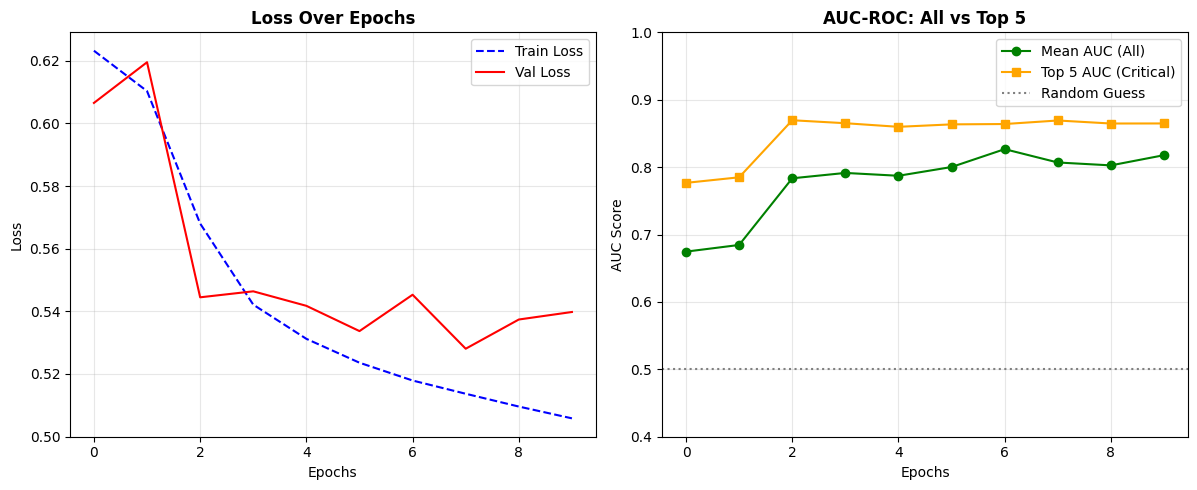

(True,
 DenseNet(
   (features): Sequential(
     (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
     (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu0): ReLU(inplace=True)
     (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
     (denseblock1): _DenseBlock(
       (denselayer1): _DenseLayer(
         (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu1): ReLU(inplace=True)
         (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
         (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu2): ReLU(inplace=True)
         (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       )
       (denselayer2): _DenseLayer(
         (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_s

In [18]:
LoadModels()